# Validation Decision-Loss Distribution

Per-day `f_dfl` (the decision-focused loss term -- realised economic cost from the
1-stage decision, clamped >=0) computed on the **validation set** (2019 H1, 181 days),
one boxplot per forecaster, one figure per market. This is the same `f_dfl` every
checkpoint's own `val_fsurr` (used for early stopping during training) is built from --
reused directly via `dfl_loss_batch`/`evaluate_regret`'s own machinery (same `fp`,
`gamma=1e-4` matching the TRAINING-time convention, not evaluation's `gamma=0`, same
1-stage LP, same copula) -- but collecting the **per-day value** rather than the single
aggregate scalar `evaluate_regret` normally reduces to.

**Scope**: two figures, one per market (single-price, dual-price), four boxes each
(Baseline, Control, DFL single-price, DFL dual-price) -- matching the native + cross-eval
structure used throughout `8_testing/economic_results.ipynb` and elsewhere: each DFL arm
is native in one figure and cross-evaluated in the other (its checkpoint's quantiles run
through the *other* mode's 1-stage decision problem and settlement). Baseline and the
CRPS-only control are price-agnostic, so they appear natively in both. Each retrained
family's box pools all 5 seeds' per-day values together (5 x 181 = 905 points), not a
separate box per seed -- one distribution per forecaster, as asked.

**Caveat worth being aware of**: unlike everything else in `8_testing/`, this is NOT the
recourse-aware `setup_full_robust` deployment formulation -- it's the 1-stage training
surrogate itself (no `D_ch`/`D_dis`), the same formulation actually used during training,
which is the point here (reproducing what the training loop's own validation signal looks
like), not a deployment-realistic cost estimate.

## Setup

In [1]:
from __future__ import annotations
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "7_model_training"))
from dfl_train_utils import (
    FORECASTING_DIR, DFL_TRAIN_DIR, COPULA_DIR, GAMMA, device,
    normalise_hist, normalise_exo, denormalise_y, Baseline_Forecaster,
    FrozenCopulaSampler, make_fp, make_bundle, make_layer, dfl_loss_batch,
)
from train_dfl_forecasts import load_data
import pickle

SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]
DEFAULT_SEED = 20240801
FAMILY_BASE_ID = {
    "Baseline": None,
    "Control": "crps_only_retrained",
    "DFL Single-price": "dfl_1stage_single-price",
    "DFL Dual-price": "dfl_1stage_dual-price",
}
FAMILY_ORDER = list(FAMILY_BASE_ID)
FAMILY_COLORS = {"Baseline": "C0", "Control": "grey", "DFL Single-price": "C6", "DFL Dual-price": "C3"}
MODES = ["single-price", "dual-price"]


def seed_variant(base_id, seed):
    return base_id if seed == DEFAULT_SEED else f"{base_id}_seed{seed}"


print("loading validation windows...")
_train_windows, val_windows = load_data()
n_val = len(val_windows.delivery_start)
print(f"n_val_days={n_val}")

baseline_ckpt = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = baseline_ckpt["scaler_stats"]
baseline_model = Baseline_Forecaster(**baseline_ckpt["model_config"])
baseline_model.load_state_dict(baseline_ckpt["state_dict"])
baseline_model = baseline_model.to(device)


def load_dfl(forecaster_id):
    ck = torch.load(DFL_TRAIN_DIR / f"{forecaster_id}.pt", weights_only=False, map_location="cpu")
    m = Baseline_Forecaster(**baseline_ckpt["model_config"])
    m.load_state_dict(ck["state_dict"])
    return m.to(device)


cop = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
sampler = FrozenCopulaSampler(cop["Z_corr"], cop["quantile_levels"]).to(device)
fwd = {"normalise_hist": normalise_hist, "denormalise_y": denormalise_y, "normalise_exo": normalise_exo}

# Balanced archetype, gamma=1e-4 -- the TRAINING-time convention (not eval's gamma=0),
# since this reproduces the training loop's own validation signal.
fp = make_fp("1stage", gamma=GAMMA)
print(f"fp: C_ch={fp.C_ch} C_dis={fp.C_dis} B_max={fp.B_max} gamma={fp.gamma}")

loading validation windows...
[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
n_val_days=181
fp: C_ch=2.0 C_dis=2.0 B_max=4.0 gamma=0.0001


### Per-day validation `f_dfl` collection

For each mode, build the 1-stage decision layer once and reuse it across every
forecaster-seed. For each forecaster-seed, loop over all 181 validation days calling
`dfl_loss_batch` with a batch of exactly one day (mirroring `evaluate_regret`'s own
per-day loop) and keep the per-day `f_dfl` value instead of accumulating a running
total.

In [2]:
def collect_val_fdfl(model, mode, layer, keys):
    """(n_val,) array of per-day f_dfl on the validation set, NaN for any day the
    solver fails on both ECOS and SCS (mirrors evaluate_regret's skip-and-continue)."""
    model.eval()
    vals = np.full(n_val, np.nan)
    with torch.no_grad():
        for d in range(n_val):
            try:
                _combined, _n, _sat_h, _n_h, _L_base_sum, f_dfl_sum, _n_inacc, _t = dfl_loss_batch(
                    [d], model=model, fp=fp, sampler=sampler, sc=sc, windows=val_windows,
                    layer=layer, keys=keys, mode=mode, device=device, fwd=fwd)
                vals[d] = f_dfl_sum
            except RuntimeError:
                continue
    return vals


RESULTS = {}   # (mode, family) -> pooled (n_seeds * n_val,) array
for mode in MODES:
    print(f"building 1-stage decision layer for mode={mode}...", flush=True)
    bundle = make_bundle("1stage", fp, mode)
    layer = make_layer(bundle)
    keys = [p.name() for p in bundle.params]
    for family in FAMILY_ORDER:
        base_id = FAMILY_BASE_ID[family]
        seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
        pooled = []
        for seed in seeds:
            model = baseline_model if family == "Baseline" else load_dfl(seed_variant(base_id, seed))
            vals = collect_val_fdfl(model, mode, layer, keys)
            n_nan = np.isnan(vals).sum()
            if n_nan:
                print(f"  {mode}/{family}/seed={seed}: {n_nan} day(s) skipped (solver failure)")
            pooled.append(vals[~np.isnan(vals)])
        RESULTS[(mode, family)] = np.concatenate(pooled)
        print(f"  collected {mode}/{family}: n={len(RESULTS[(mode, family)])} pooled points "
              f"(mean={RESULTS[(mode, family)].mean():.3f})", flush=True)

building 1-stage decision layer for mode=single-price...


  collected single-price/Baseline: n=181 pooled points (mean=2561.269)


  collected single-price/Control: n=905 pooled points (mean=2560.813)


  collected single-price/DFL Single-price: n=905 pooled points (mean=2560.392)


  collected single-price/DFL Dual-price: n=905 pooled points (mean=2560.890)


building 1-stage decision layer for mode=dual-price...


  collected dual-price/Baseline: n=181 pooled points (mean=2603.300)


  collected dual-price/Control: n=905 pooled points (mean=2602.992)


  collected dual-price/DFL Single-price: n=905 pooled points (mean=2603.219)


  collected dual-price/DFL Dual-price: n=905 pooled points (mean=2602.730)


## Boxplots -- per-day validation decision-loss, by forecaster

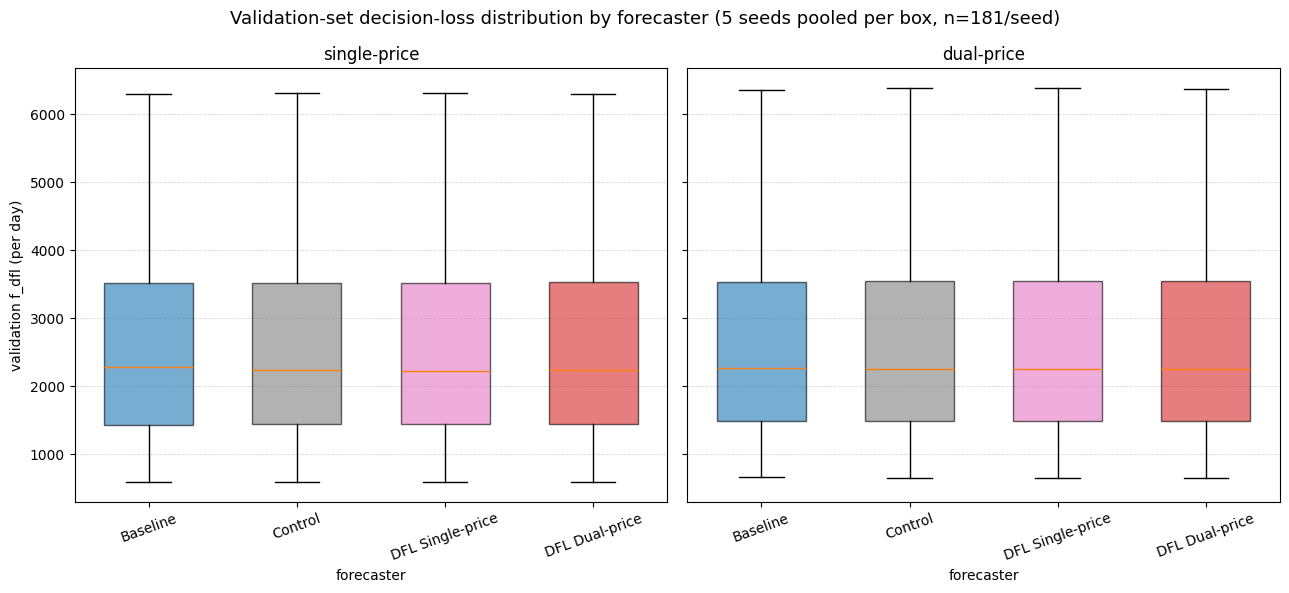

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, mode in zip(axes, MODES):
    data = [RESULTS[(mode, family)] for family in FAMILY_ORDER]
    bp = ax.boxplot(data, tick_labels=FAMILY_ORDER, showfliers=True, patch_artist=True, widths=0.6)
    for patch, family in zip(bp["boxes"], FAMILY_ORDER):
        patch.set_facecolor(FAMILY_COLORS[family])
        patch.set_alpha(0.6)
    ax.set_title(mode)
    ax.set_xlabel("forecaster")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
axes[0].set_ylabel("validation f_dfl (per day)")
fig.suptitle("Validation-set decision-loss distribution by forecaster (5 seeds pooled per box, n=181/seed)", fontsize=13)
fig.tight_layout()
plt.show()